# Unsupervised Swiss Roll Leaf Embeddings

Compare 2D embeddings of common sklearn embedders with uniform leaf-incidence maps from an **unsupervised** `RandomTreesEmbedding` forest and a **supervised** `RandomForestClassifier` trained on six Swiss roll partitions.

In [27]:
from pathlib import Path
import sys

repo_root = Path.cwd().parent if Path.cwd().name == "demos" else Path.cwd()
src_path = repo_root / "src"
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import make_swiss_roll
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier, RandomTreesEmbedding
from sklearn.manifold import Isomap, LocallyLinearEmbedding, SpectralEmbedding, TSNE
from sklearn.preprocessing import StandardScaler

from forestgeom import ForestProximity

In [28]:
seed = 42
embedding_method_list = ["pca",
                         "tsne",
                         "spectral",
                         "isomap",
                         "lle"]
n_samples = 1800
n_labels = 6

X, t = make_swiss_roll(
    n_samples=n_samples,
    noise=0.15,
    random_state=seed,
)
X = StandardScaler().fit_transform(X)

# Six labels that partition the roll along its intrinsic unrolled coordinate.
label_edges = np.quantile(t, np.linspace(0.0, 1.0, n_labels + 1))
labels = np.digitize(t, label_edges[1:-1], right=False)

In [ ]:
rte = RandomTreesEmbedding(
    random_state=seed,
    n_jobs=-1,
)

rf = RandomForestClassifier(
    random_state=seed,
    n_jobs=-1,
)

rte_geom = ForestProximity(forest=rte, weight_scheme="uniform").fit(X)
rf_geom = ForestProximity(forest=rf, weight_scheme="uniform").fit(X, labels)

# We set to dense for the demo, but most sklearn embedding methods can work with sparse input
rte_leaf = rte_geom.query_map(return_dense=True)
rf_leaf = rf_geom.query_map(return_dense=True)

In [32]:
def leaf_embedding(leaf_map, method):
    leaf_map = leaf_map.toarray() if hasattr(leaf_map, "toarray") else leaf_map
    method = method.lower()
    if method == "pca":
        return PCA(n_components=2,random_state=seed).fit_transform(leaf_map)
    if method == "tsne":
        return TSNE(
            n_components=2,
            perplexity=50,
            random_state=seed,
        ).fit_transform(leaf_map)
    if method == "spectral":
        return SpectralEmbedding(
            n_components=2,
            n_neighbors=10,
            random_state=seed,
        ).fit_transform(leaf_map)
    if method == "isomap":
        return Isomap(
            n_components=2,
            n_neighbors=7,
        ).fit_transform(leaf_map)
    if method == "lle":
        return LocallyLinearEmbedding(
            n_components=2,
            n_neighbors=10,
            random_state=seed,
        ).fit_transform(leaf_map)
    raise ValueError("embedding_method must be 'pca', 'tsne', 'spectral', 'isomap', or 'lle'.")


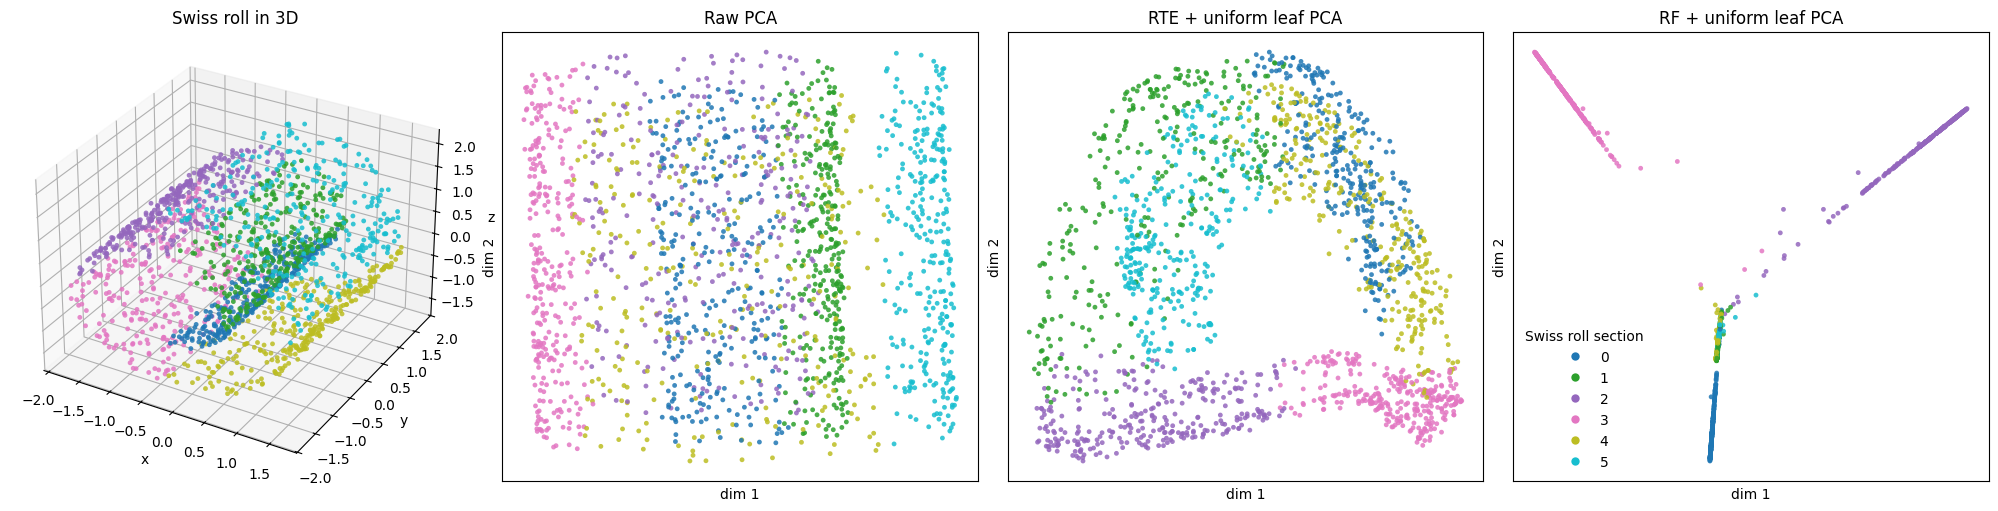

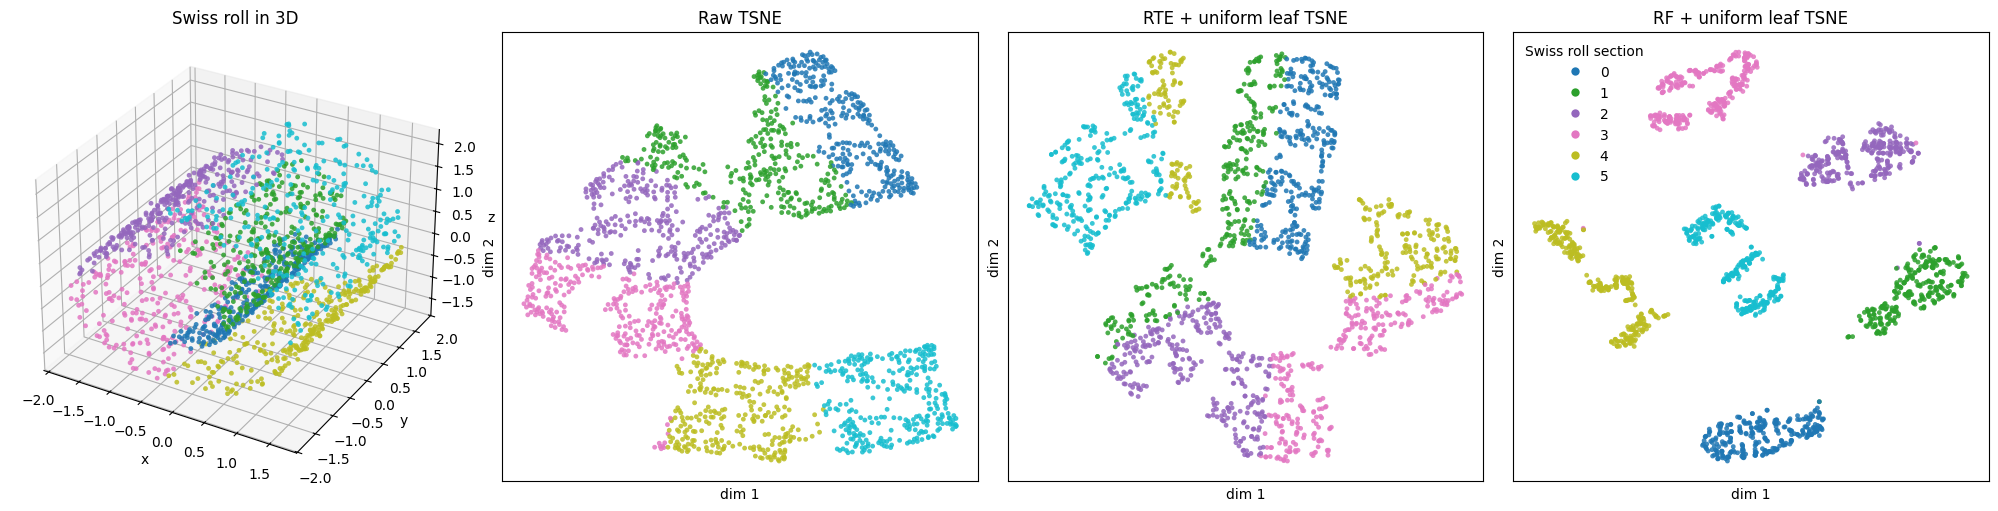

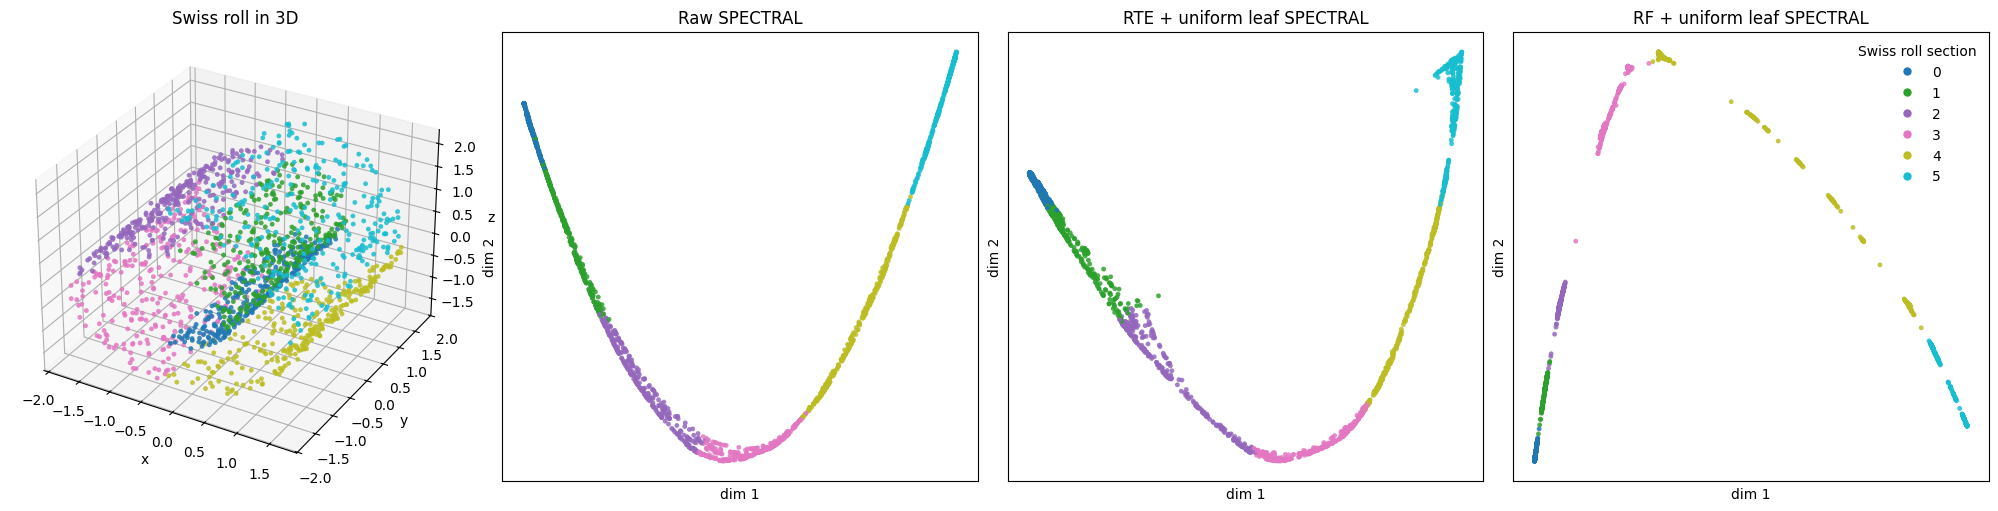

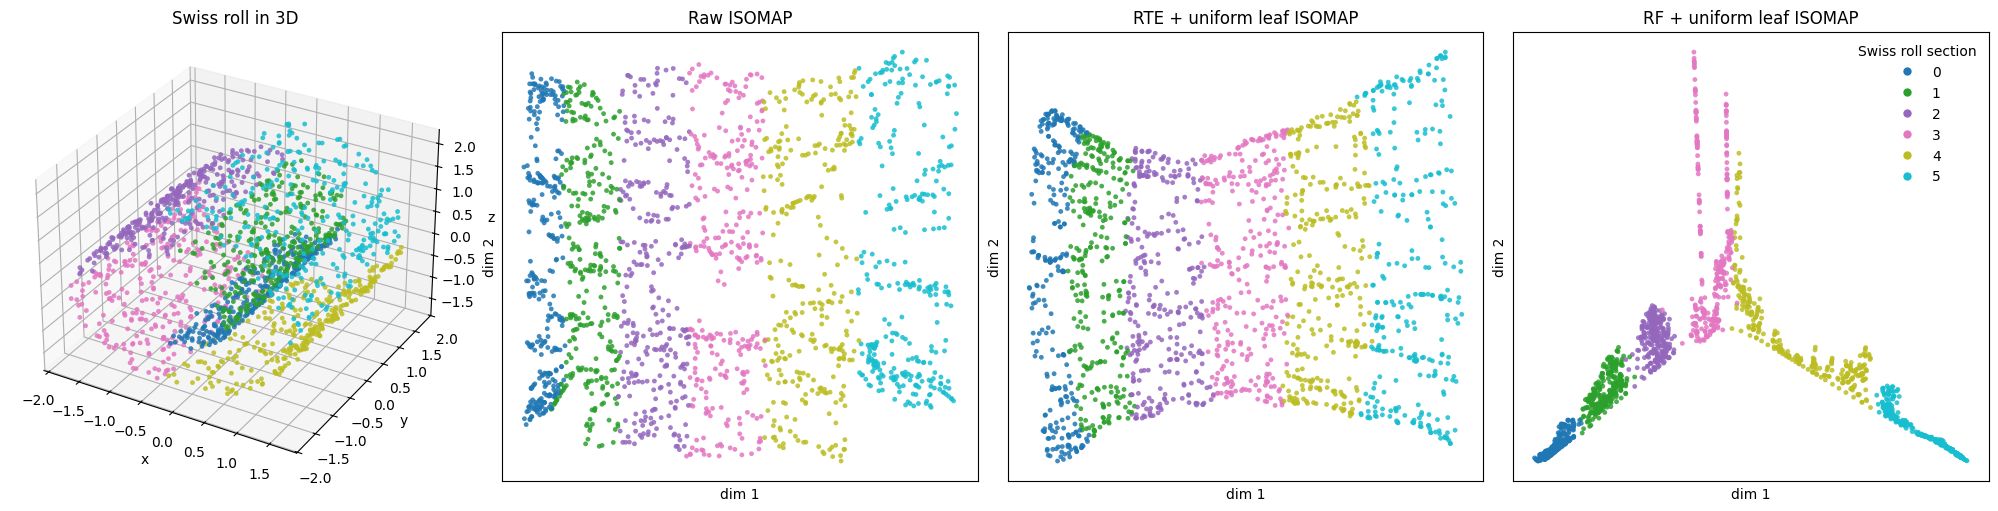

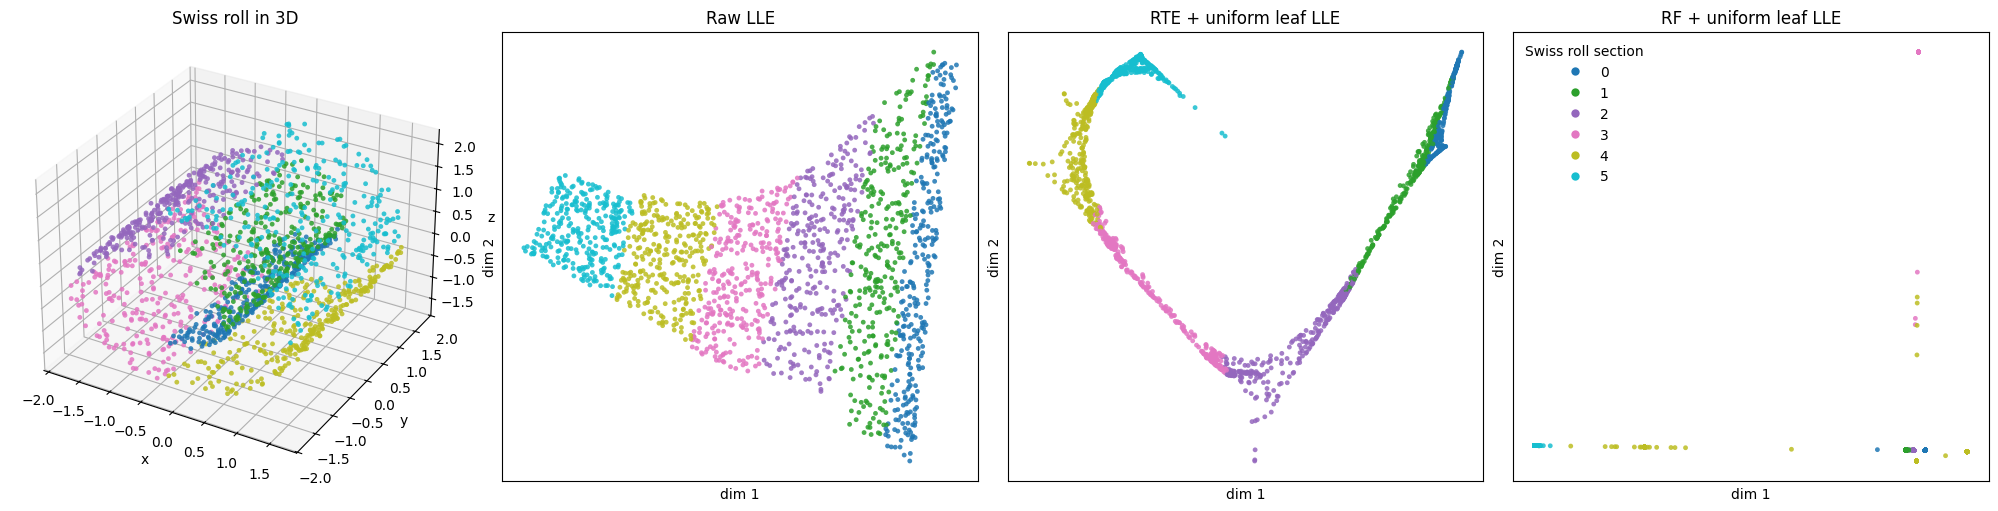

In [33]:
cmap = plt.get_cmap("tab10", n_labels)

for embedding_method in embedding_method_list:
    Z_raw = leaf_embedding(X, embedding_method)
    Z_rte = leaf_embedding(rte_leaf, embedding_method)
    Z_rf = leaf_embedding(rf_leaf, embedding_method)

    fig = plt.figure(figsize=(20, 5), constrained_layout=True)
    axes = [
        fig.add_subplot(1, 4, 1, projection="3d"),
        fig.add_subplot(1, 4, 2),
        fig.add_subplot(1, 4, 3),
        fig.add_subplot(1, 4, 4),
    ]

    axes[0].scatter(
        X[:, 0],
        X[:, 1],
        X[:, 2],
        c=labels,
        cmap=cmap,
        s=12,
        alpha=0.85,
        linewidths=0,
    )
    axes[0].set_title("Swiss roll in 3D")
    axes[0].set_xlabel("x")
    axes[0].set_ylabel("y")
    axes[0].set_zlabel("z")

    plots = [
        (axes[1], Z_raw, f"Raw {embedding_method.upper()}"),
        (axes[2], Z_rte, f"RTE + uniform leaf {embedding_method.upper()}"),
        (axes[3], Z_rf, f"RF + uniform leaf {embedding_method.upper()}"),
    ]

    for ax, Z, title in plots:
        ax.scatter(
            Z[:, 0],
            Z[:, 1],
            c=labels,
            cmap=cmap,
            s=12,
            alpha=0.85,
            linewidths=0,
        )
        ax.set_title(title)
        ax.set_xlabel("dim 1")
        ax.set_ylabel("dim 2")
        ax.set_xticks([])
        ax.set_yticks([])

    legend_handles = [
        plt.Line2D(
            [0],
            [0],
            marker="o",
            linestyle="",
            markersize=6,
            markerfacecolor=cmap(label),
            markeredgecolor="none",
            label=str(label),
        )
        for label in range(n_labels)
    ]
    axes[-1].legend(
        handles=legend_handles,
        title="Swiss roll section",
        loc="best",
        frameon=False,
    )
    plt.show()